# Lab 04 - Assignment 1

In [37]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from tabulate import tabulate

## Statistical Moments Functions

- **Raw moments**: $m_{pq} = \sum\sum x^p y^q f(x,y)$
- **Central moments**: $\mu_{pq} = \sum\sum (x-\bar{x})^p (y-\bar{y})^q f(x,y)$
- **Normalized central moments**: $\eta_{pq} = \frac{\mu_{pq}}{\mu_{00}^\gamma}$ where $\gamma = \frac{p+q}{2} + 1$

In [38]:
def compute_moments(img):
    M, N = img.shape
    moments = {}
    
    for p in range(4):
        for q in range(4):
            if p + q <= 3:
                moment = 0
                for x in range(M):
                    for y in range(N):
                        moment += (x ** p) * (y ** q) * img[x, y]
                moments[f'm_{p}{q}'] = moment
    
    return moments

In [39]:
def compute_central_moments(img, moments):
    M, N = img.shape

    x_bar = moments['m_10'] / moments['m_00'] if moments['m_00'] != 0 else 0
    y_bar = moments['m_01'] / moments['m_00'] if moments['m_00'] != 0 else 0
    
    central_moments = {}
    
    for p in range(4):
        for q in range(4):
            if p + q <= 3:
                mu = 0
                for x in range(M):
                    for y in range(N):
                        mu += ((x - x_bar) ** p) * ((y - y_bar) ** q) * img[x, y]
                central_moments[f'mu_{p}{q}'] = mu
    
    return central_moments, x_bar, y_bar


In [40]:
def compute_normalized_central_moments(central_moments):
    normalized = {}
    mu_00 = central_moments['mu_00']
    
    for p in range(4):
        for q in range(4):
            if p + q >= 2 and p + q <= 3:
                gamma = (p + q) / 2 + 1
                key = f'eta_{p}{q}'
                mu_key = f'mu_{p}{q}'
                normalized[key] = central_moments[mu_key] / (mu_00 ** gamma) if mu_00 != 0 else 0
    
    return normalized


## Hu Moment Invariants

The 7 Hu moment invariants are:
- $\phi_1 = \eta_{20} + \eta_{02}$
- $\phi_2 = (\eta_{20} - \eta_{02})^2 + 4\eta_{11}^2$
- $\phi_3 = (\eta_{30} - 3\eta_{12})^2 + (3\eta_{21} - \eta_{03})^2$
- $\phi_4 = (\eta_{30} + \eta_{12})^2 + (\eta_{21} + \eta_{03})^2$
- And phi5, φ6, φ7 (more complex)

These moments are invariant to:
- Translation
- Scale
- Rotation
- Mirroring (within a sign)

In [41]:
def compute_hu_moments(eta):
    n20 = eta.get('eta_20', 0)
    n02 = eta.get('eta_02', 0)
    n11 = eta.get('eta_11', 0)
    n30 = eta.get('eta_30', 0)
    n12 = eta.get('eta_12', 0)
    n21 = eta.get('eta_21', 0)
    n03 = eta.get('eta_03', 0)
    
    phi1 = n20 + n02
    
    phi2 = (n20 - n02)**2 + 4 * n11**2
    
    phi3 = (n30 - 3*n12)**2 + (3*n21 - n03)**2
    
    phi4 = (n30 + n12)**2 + (n21 + n03)**2
    
    phi5 = ((n30 - 3*n12) * (n30 + n12) * 
            ((n30 + n12)**2 - 3*(n21 + n03)**2) +
            (3*n21 - n03) * (n21 + n03) * 
            (3*(n30 + n12)**2 - (n21 + n03)**2))
    
    phi6 = ((n20 - n02) * ((n30 + n12)**2 - (n21 + n03)**2) +
            4*n11 * (n30 + n12) * (n21 + n03))
    
    phi7 = ((3*n21 - n03) * (n30 + n12) * 
            ((n30 + n12)**2 - 3*(n21 + n03)**2) +
            (3*n21 - n30) * (n21 + n03) * 
            (3*(n30 + n12)**2 - (n21 + n03)**2))
    
    return [phi1, phi2, phi3, phi4, phi5, phi6, phi7]

In [42]:
def get_hu_moments(img):
    img_normalized = img.astype(np.float64) / 255.0
    
    moments = compute_moments(img_normalized)
    central_moments, x_bar, y_bar = compute_central_moments(img_normalized, moments)
    normalized_moments = compute_normalized_central_moments(central_moments)
    hu_moments = compute_hu_moments(normalized_moments)
    
    return hu_moments[:4]


## Distance Metric: Chi-Squared Distance

$$\chi^2 = 0.5 \sum_i \frac{(f_{1i} - f_{2i})^2}{f_{1i} + f_{2i}}$$

In [43]:
def chi_squared_distance(features1, features2):
    features1 = np.array(features1)
    features2 = np.array(features2)
    
    distance = 0
    for i in range(len(features1)):
        denominator = features1[i] + features2[i]
        if denominator != 0:
            distance += ((features1[i] - features2[i]) ** 2) / denominator
    
    return 0.5 * distance

## Image Transformations

In [44]:
def apply_transformations(img):
    h, w = img.shape
    center = (w // 2, h // 2)
    
    transformations = {}
    transformations['Original'] = img.copy()
    
    M_rot = cv2.getRotationMatrix2D(center, 45, 1.0)
    transformations['Rotated 45°'] = cv2.warpAffine(img, M_rot, (w, h))
    
    transformations['Scaled 0.5x'] = cv2.resize(img, None, fx=0.5, fy=0.5)
    transformations['Scaled 0.5x'] = cv2.resize(transformations['Scaled 0.5x'], (w, h))
    
    transformations['Mirrored'] = cv2.flip(img, 1)

    alpha = 1.5  # Contrast control
    beta = 10    # Brightness control
    transformations['Contrast Enhanced'] = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
    
    M_rot_scale = cv2.getRotationMatrix2D(center, 30, 0.8)
    transformations['Rotated 30° + Scaled'] = cv2.warpAffine(img, M_rot_scale, (w, h))
    
    return transformations

## Load Images

In [45]:
images = []
image_names = ['Lena.jpg', 'buildings.jpg', 'edge.png', 'col.jpg']

for name in image_names:
        img = cv2.imread(f'../../../assets/{name}', cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (256, 256))
        images.append(img)

base_img = images[0]

## Apply Transformations to All Images

In [46]:
all_transformations = {}
for idx, img in enumerate(images[:4]):
    all_transformations[f'Image {idx+1}'] = apply_transformations(img)

print(f"  Total variants: {len(all_transformations) * 6}")

  Total variants: 24


### Visualize Image Transformations

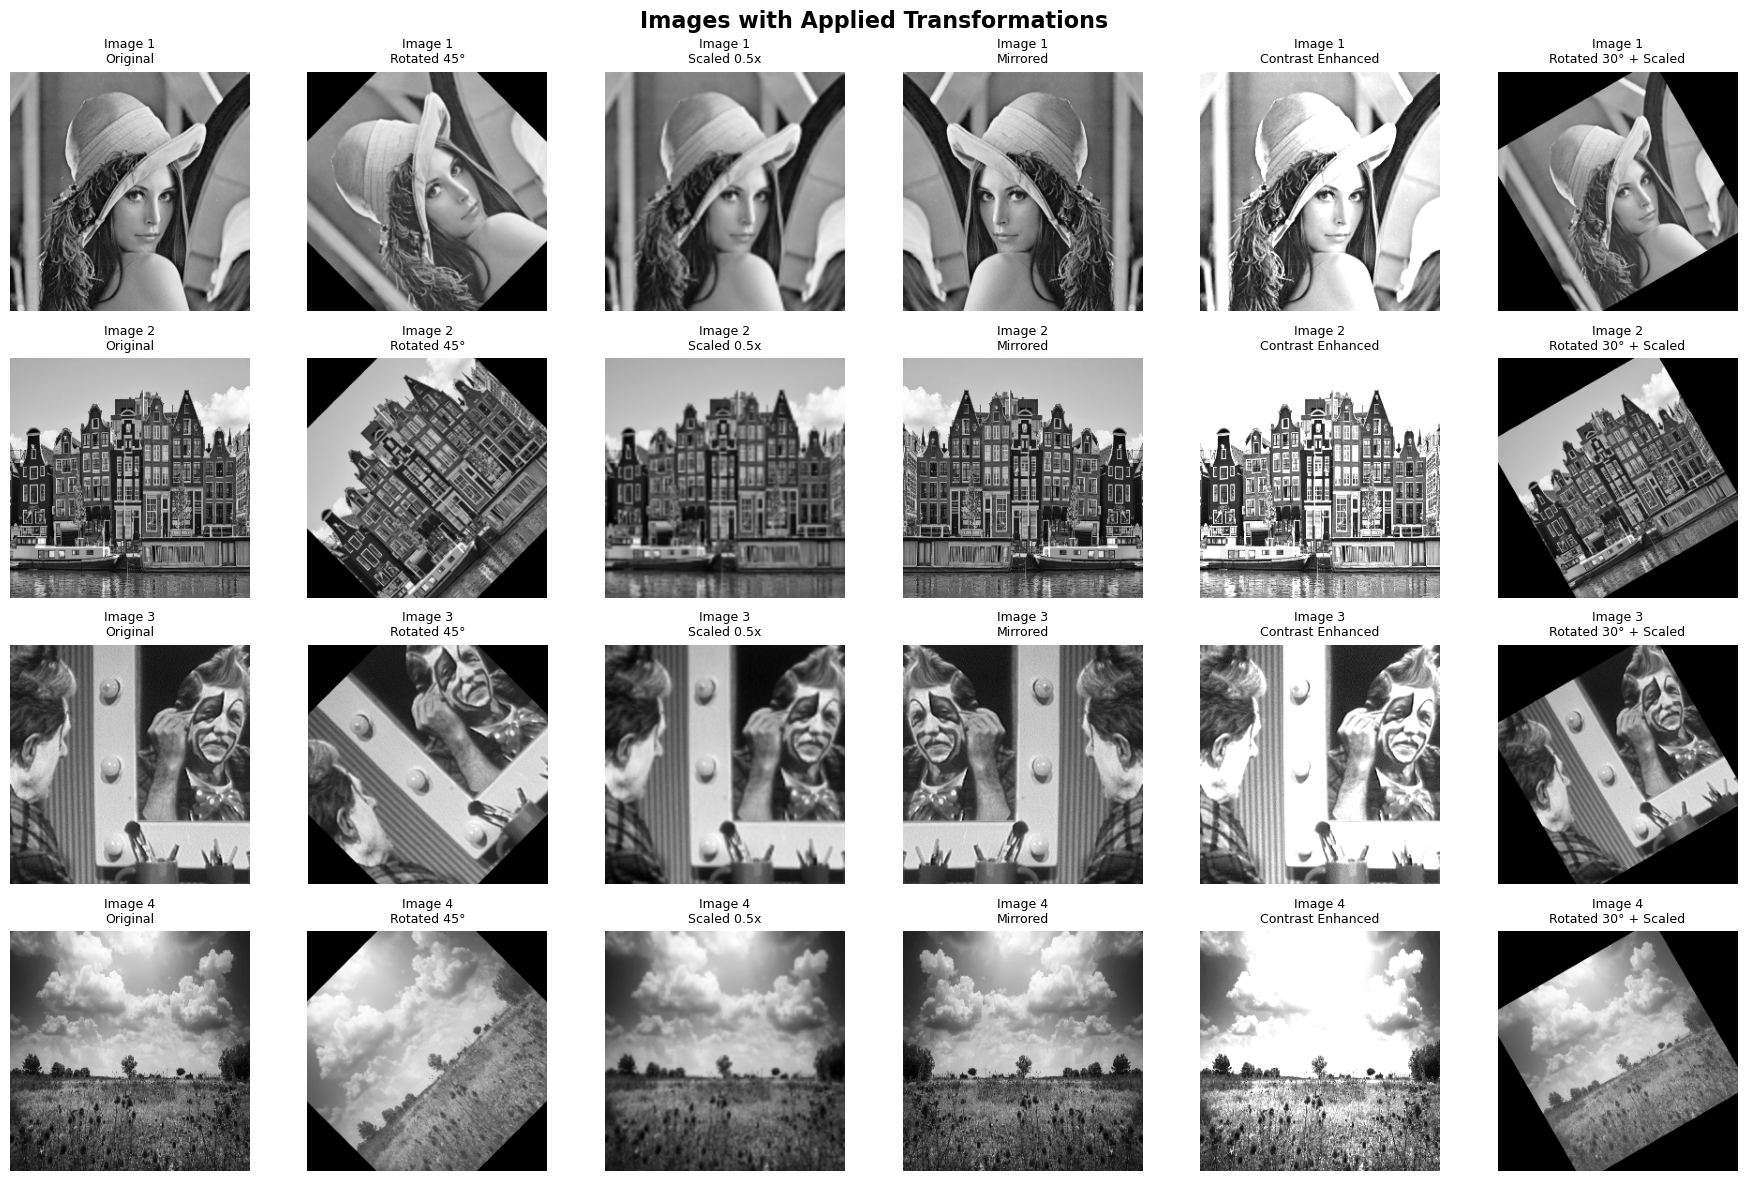

In [47]:
fig1, axes = plt.subplots(4, 6, figsize=(18, 12))
fig1.suptitle('Images with Applied Transformations', fontsize=16, fontweight='bold')

for idx, (img_name, transforms) in enumerate(all_transformations.items()):
    if idx >= 4:
        break
    for jdx, (trans_name, trans_img) in enumerate(transforms.items()):
        axes[idx, jdx].imshow(trans_img, cmap='gray')
        axes[idx, jdx].set_title(f"{img_name}\n{trans_name}", fontsize=9)
        axes[idx, jdx].axis('off')

plt.tight_layout()
plt.show()

## Compute Hu Moments for All Variants

In [48]:
hu_moments_table = []
image_labels = []

for img_name, transforms in all_transformations.items():
    for trans_name, trans_img in transforms.items():
        hu = get_hu_moments(trans_img)
        hu_moments_table.append(hu)
        image_labels.append(f"{img_name} - {trans_name}")

### Display Hu Moments Table

In [49]:
print("Hu Moments:")


headers = ['Image Variant', 'phi1', 'phi2', 'phi3', 'phi4']
table_data = [[label] + [f"{val:.6f}" for val in hu] for label, hu in zip(image_labels, hu_moments_table)]
print(tabulate(table_data, headers=headers, tablefmt='grid'))

Hu Moments:
+--------------------------------+----------+----------+----------+----------+
| Image Variant                  |     phi1 |     phi2 |     phi3 |     phi4 |
+================================+==========+==========+==========+==========+
| Image 1 - Original             | 0.338611 | 0.000432 | 1.9e-05  | 0.000185 |
+--------------------------------+----------+----------+----------+----------+
| Image 1 - Rotated 45°          | 0.325074 | 0.000502 | 0.000114 | 0.000149 |
+--------------------------------+----------+----------+----------+----------+
| Image 1 - Scaled 0.5x          | 0.338451 | 0.000431 | 1.9e-05  | 0.000185 |
+--------------------------------+----------+----------+----------+----------+
| Image 1 - Mirrored             | 0.338611 | 0.000432 | 1.9e-05  | 0.000185 |
+--------------------------------+----------+----------+----------+----------+
| Image 1 - Contrast Enhanced    | 0.224253 | 0.000143 | 2e-06    | 3.4e-05  |
+--------------------------------+------

### Visualize Hu Moments Invariance

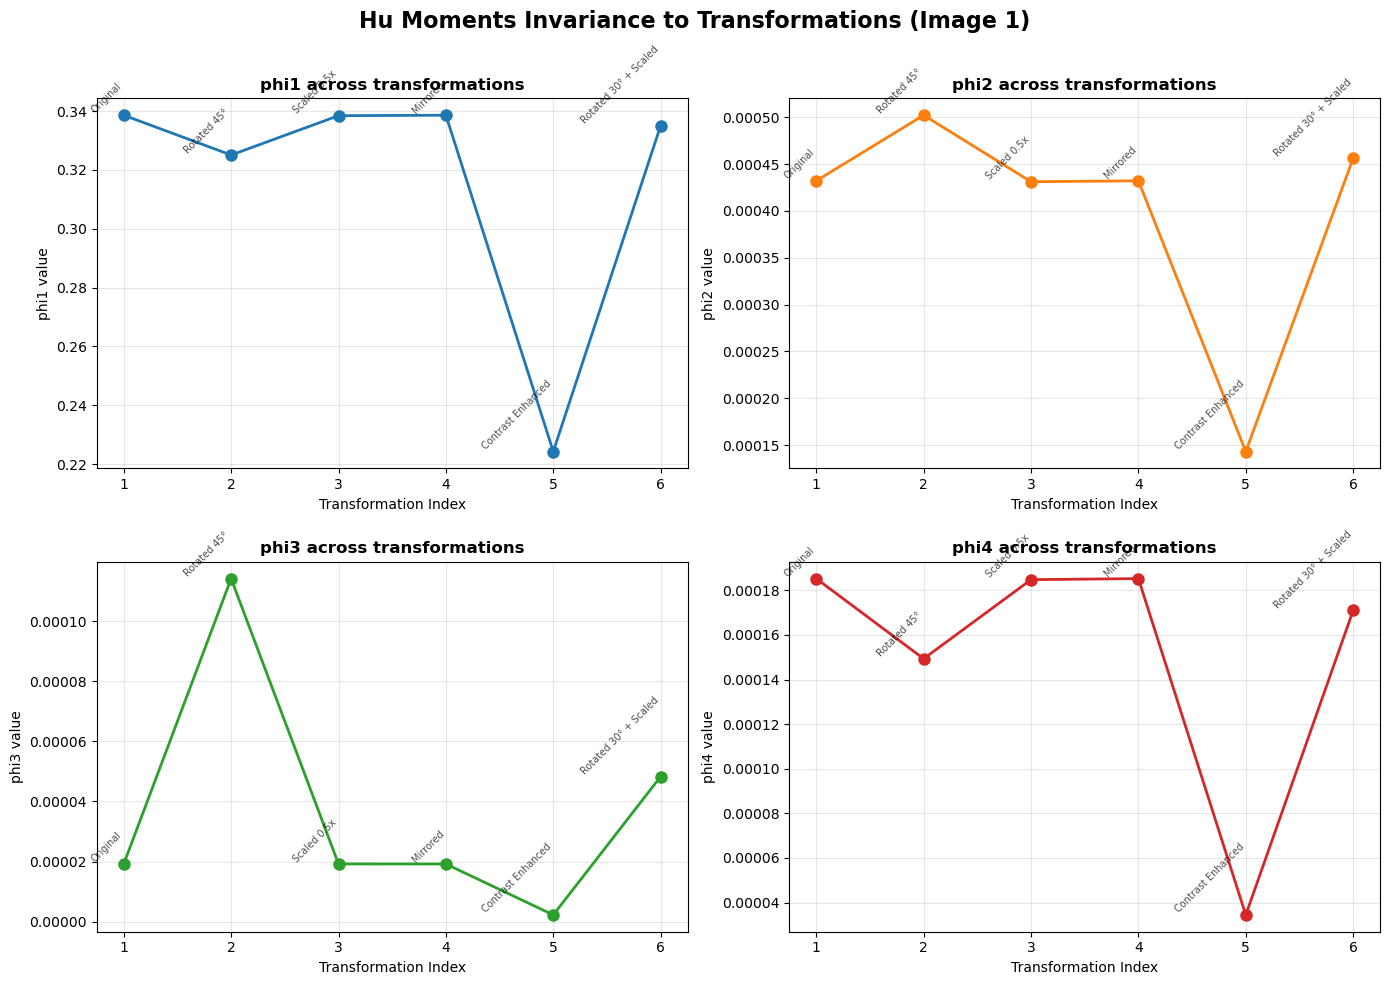

In [50]:
fig2, axes = plt.subplots(2, 2, figsize=(14, 10))
fig2.suptitle('Hu Moments Invariance to Transformations (Image 1)', fontsize=16, fontweight='bold')

first_img_transforms = list(all_transformations['Image 1'].keys())
first_img_hu = [get_hu_moments(all_transformations['Image 1'][t]) for t in first_img_transforms]
first_img_hu = np.array(first_img_hu)

for i in range(4):
    ax = axes[i // 2, i % 2]
    ax.plot(range(len(first_img_transforms)), first_img_hu[:, i], 'o-', linewidth=2, markersize=8, color=f'C{i}')
    ax.set_title(f'phi{i+1} across transformations', fontsize=12, fontweight='bold')
    ax.set_xlabel('Transformation Index')
    ax.set_ylabel(f'phi{i+1} value')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(len(first_img_transforms)))
    ax.set_xticklabels(range(1, len(first_img_transforms)+1))
    
    # Add transformation labels
    for j, label in enumerate(first_img_transforms):
        ax.text(j, first_img_hu[j, i], label, rotation=45, 
                ha='right', va='bottom', fontsize=7, alpha=0.7)

plt.tight_layout()
plt.show()

## Compare query images with the base image using Chi-squared distance.

In [ ]:
base_hu = get_hu_moments(base_img)
print("Base Image Hu Moments:")
print(f"  phi1 = {base_hu[0]:.6f}")
print(f"  phi2 = {base_hu[1]:.6f}")
print(f"  phi3 = {base_hu[2]:.6f}")
print(f"  phi4 = {base_hu[3]:.6f}")

print("\nComparing query images with base image:")
query_distances = []
for i in range(1, 4):
    query_hu = get_hu_moments(images[i])
    dist = chi_squared_distance(base_hu, query_hu)
    query_distances.append((f"Image {i+1}", dist))
    print(f"  Image {i+1} vs Base: chi^2 = {dist:.6f}")


best_match = min(query_distances, key=lambda x: x[1])
print(f"\nBest match: {best_match[0]}, distance {best_match[1]:.6f}")

Base Image Hu Moments:
  phi1 = 0.338611
  phi2 = 0.000432
  phi3 = 0.000019
  phi4 = 0.000185

Comparing query images with base image:
  Image 2 vs Base: chi^2 = 0.001670
  Image 3 vs Base: chi^2 = 0.000446
  Image 4 vs Base: chi^2 = 0.004270

Best match: Image 3, distance 0.000446


### Visualize Chi-Squared Distances

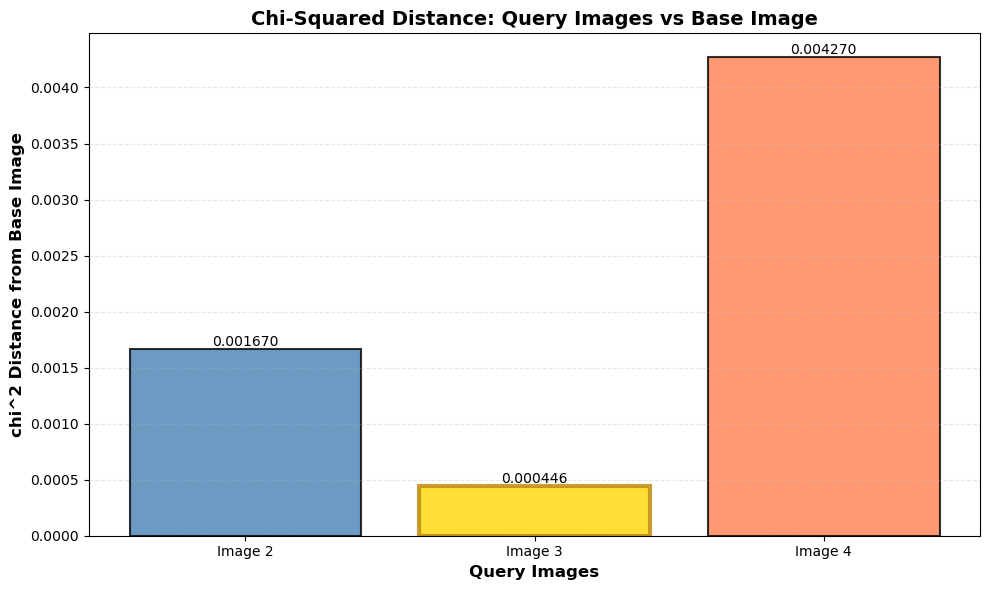

In [52]:
if len(images) >= 4 and query_distances:
    fig3, ax = plt.subplots(figsize=(10, 6))
    
    distances = [d[1] for d in query_distances]
    labels = [d[0] for d in query_distances]
    
    bars = ax.bar(labels, distances, color=['steelblue', 'seagreen', 'coral'][:len(distances)], 
                edgecolor='black', linewidth=1.5, alpha=0.8)
    ax.set_xlabel('Query Images', fontsize=12, fontweight='bold')
    ax.set_ylabel('chi^2 Distance from Base Image', fontsize=12, fontweight='bold')
    ax.set_title('Chi-Squared Distance: Query Images vs Base Image', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    
    if query_distances:
        best_idx = distances.index(min(distances))
        bars[best_idx].set_color('gold')
        bars[best_idx].set_edgecolor('darkgoldenrod')
        bars[best_idx].set_linewidth(3)

    for i, (bar, dist) in enumerate(zip(bars, distances)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{dist:.6f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
